## imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist, pdist
from scipy.signal import resample
from scipy.stats import zscore, pearsonr
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns

%matplotlib inline

## set paths

In [2]:
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [3]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## shorten some frequent variables

In [4]:
pred_trajs = participant_trajectories['prediction']
avg_pred_traj = avg_participant_trajectories['prediction']
pred_events = participant_events['prediction']
avg_pred_events = avg_participant_events['prediction']
atlep2_traj = episode_trajectories['atlep2']
atlep2_events = episode_events['atlep2']
atlep2_rec_trajs = participant_trajectories['atlep2']
avg_atlep2_rec_traj = avg_participant_trajectories['atlep2']
atlep2_rec_events = participant_events['atlep2']
avg_atlep2_rec_events = avg_participant_events['atlep2']

## define some functions

In [5]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [6]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [7]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

In [11]:
def corr_pearsonr(rs1, rs2):
    return _z2r(np.array(pearsonr(_r2z(np.array(rs1)), _r2z(np.array(rs2)))))

In [8]:
## for plotting error bars
def ribbon(M, color='k', alpha=0.5):    
    x = np.arange(M.shape[0])
    y = np.mean(M, axis=1)
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

## filter events with no predictions from average prediction events

In [9]:
no_rec_mask = np.all(np.equal(avg_pred_events, 0), axis=1)
avg_pred_events = avg_pred_events[~no_rec_mask]

## filter atlep2 recall events with no recalls from average

In [10]:
no_rec_mask = np.all(np.equal(avg_atlep2_rec_events, 0), axis=1)
avg_atlep2_rec_events = avg_atlep2_rec_events[~no_rec_mask]

## does content of prediction relate to content of eventually remembered moments?

In [13]:
# # list of correlation coefficients per subject
# pred_corrs = []
# rec_corrs = []
# # for each participant who viewed atlep2
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session study ID and session 1 psiturk ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)
    
#     # get their prediction and atlep2 recall trajectories
#     sub_pred_traj = next(p_traj for tid, p_traj in pred_trajs if tid == turkid1)
#     sub_atlep2_rec_traj = next(r_traj for tid, r_traj in atlep2_rec_trajs if tid == turkid2)
    
#     tpt_pred_corr = []
#     tpt_rec_corr = []
#     # for each prediction timepoint
#     for tpt in sub_pred_traj:
#         # find the most similar atlep2 TIMEPOINT and its index
#         maxcorr_p = np.max(1-cdist(np.atleast_2d(tpt),atlep2_traj, 'correlation'))
#         maxcorr_ix = np.argmax(1-cdist(np.atleast_2d(tpt), atlep2_traj, 'correlation'))
        
#         # find distance from that atlep2 timepoint to nearest recall timepoint
#         maxcorr_r = np.max(1-cdist([atlep2_traj[maxcorr_ix]], sub_atlep2_rec_traj, 'correlation'))
        
#         tpt_pred_corr.append(maxcorr_p)
#         tpt_rec_corr.append(maxcorr_r)
        
#     pred_corrs.append(corr_mean(tpt_pred_corr))
#     rec_corrs.append(corr_mean(tpt_rec_corr))

#     #corrs.append(list(pearsonr(tpt_pred_dist, tpt_rec_dist)))

# #print(np.mean(corrs, axis=0))

In [16]:
# sns.jointplot(pred_corrs, rec_corrs, kind='reg', stat_func=corr_pearsonr)

## are atlep2 recalls "pulled toward" predictions?

In [18]:
# for each participant who viewed atlep2
for turkid2, events in participant_events['atlep2']:
    # get their across-session study ID and session 1 psiturk ID
    sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 2'] == turkid2)
    # get their atlep2 episode-recall event mappings
    recall_mappings = next(maps for tid, maps in event_mappings['atlep2'] if tid==turkid2)
    # and get their atlep2 episode-prediction event mappings
    pred_mappings = next(maps for tid, maps in event_mappings['prediction'] if tid==turkid1)
    
    # for each prediction event
    for recall_event in events:
        # get the vector from the corresponding episode event to that prediction event
        

In [57]:
# for each subject and their atlep2 recall events
for turkid2, events in participant_events['atlep2']:
    # get their across-session ID and session 1 ID
    sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 2'] == turkid2)

    # get the atlep2 events they predicted
    prediction_events = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
    
    # get their prediction/atlep2 and atlep2/recall event mappings
    prediction_mappings = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
    atlep2_mappings = next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2)
    
    # for each predicted event
    for i in prediction_mappings:
        get the 
        meanpred = prediction_events[np.where(prediction_mappings==i)].mean(axis=0)
        

#     # index mask for predicted events later recalled
#     inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
#     # if any events were both predicted and recalled
#     if any(inboth_ix):
        
#         # displacement vector and between each predicted atlep2 event and its prediction, and unit vector
#         pred_ep_disp = sub_pred_evs[np.where(np.isin(sub_pred_mappings, inboth_ix))] - atlep2_events[inboth_ix]
#         pred_ep_direc = pred_ep_disp / np.absolute(pred_ep_disp)

#         # find the displacement vector between the episode event and their later recall of it, and unit vector
#         ep_rec_disp = atlep2_events[inboth_ix] - sub_atlep2_rec_evs[np.where(np.isin(sub_atlep2_rec_mappings, inboth_ix))]
#         ep_rec_direc = ep_rec_disp / np.absolute(ep_rec_disp)


#         prediction_event_effects.loc[sid] = [pred_ep_disp, pred_ep_direc, ep_rec_disp, ep_rec_direc]
        
# prediction_event_effects.dropna(inplace=True)



In [59]:
atlep2_mappings

array([ 0,  0,  0,  0,  3,  3,  0,  0, 16, 16, 16,  8,  8, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 13, 13, 14, 14, 15, 15, 15, 15, 15, 16,  8,  8,
       15, 15, 15, 15, 15, 15, 15, 15,  5,  5,  5, 25,  6, 25, 24,  0])

In [60]:
for i in prediction_mappings:
    testpred = prediction_events[np.where(prediction_mappings==i)]
    if testpred.shape[0] > 1:
        testpred = corr_mean(testpred)


In [82]:
testpred.shape

(1, 100)

## compare prediction content to episode 2 content (WIP)

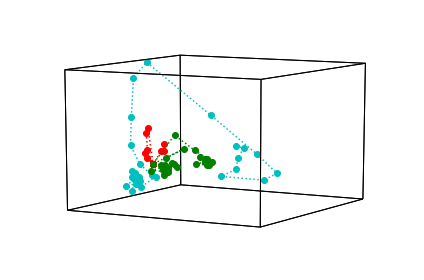

In [52]:
hyp.plot([avg_participant_events['prediction']]+[episode_events['atlep2']]+[avg_participant_events['atlep2']], fmt=
         ['ro:','co:','go:'])

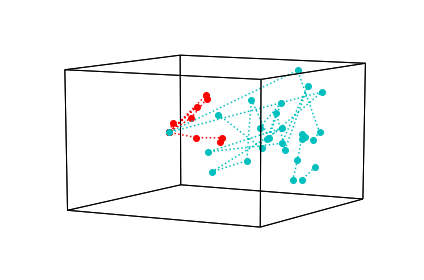

In [53]:
hyp.plot([avg_participant_events['prediction']]+[avg_participant_events['atlep2']], fmt=
         ['ro:','co:'])

## does prediction content influence event memory

In [80]:
for ep2_event in atlep2_events:
    
    # find maximally correlated prediction event
    p_event_maxcorr = np.max(1-cdist([ep2_event], avg_pred_events, 'correlation'))
    
    # relate to distance to average recall event for that episode event
    mindist_rec_ev = np.min(cdist())

0.5698048203500193
0.5279125352778792
0.5107823142671394
0.41153395236511026
0.02152456682799797
-0.029637087106140214
-0.025064001325265206
-0.029388441446564606
0.22413827347829018
0.7987471506766661
0.7065511447123237
0.45132870092077115
0.027782801275818447
-0.028441648890813243
-0.02675088169964268
-0.029978428155319037
-0.02425961721610137
-0.03306295358271538
-0.030856218306867023
-0.026665228052402234
-0.030425924102416957
-0.02281299739539122
0.16956054409416754
0.6527949727622029
0.07550942480589373
-0.021908583898202494
-0.0240323956436872


In [90]:
np.min(cdist([ep2_event], avg_atlep2_rec_events))

0.5128705345890805

## does how an episode 2 event was predicted affect how it was later remembered?

In [45]:
# # NOTE: lots of issues with repeat event matches, using first occurence of event mappings

# prediction_event_effects = pd.DataFrame(index=list(id_maps.keys()), 
#                                         columns=['pred_ep_disp','pred_ep_direc','ep_rec_disp','ep_rec_direc'])
# # for each subject and their atlep2 recall events
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session ID and session 1 ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)

#     # get the atlep2 events they predicted and those they remembered later
#     sub_pred_evs = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
#     sub_atlep2_rec_evs = next(r_evs for tid, r_evs in atlep2_rec_events if tid == turkid2)
    
#     # get their prediction/atlep2 and atlep2/recall event mappings
#     sub_pred_mappings = np.unique(next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1))
#     sub_atlep2_rec_mappings = np.unique(next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2))

#     # index mask for predicted events later recalled
#     inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
#     # if any events were both predicted and recalled
#     if any(inboth_ix):
        
#         # displacement vector and between each predicted atlep2 event and its prediction, and unit vector
#         pred_ep_disp = sub_pred_evs[np.where(np.isin(sub_pred_mappings, inboth_ix))] - atlep2_events[inboth_ix]
#         pred_ep_direc = pred_ep_disp / np.absolute(pred_ep_disp)

#         # find the displacement vector between the episode event and their later recall of it, and unit vector
#         ep_rec_disp = atlep2_events[inboth_ix] - sub_atlep2_rec_evs[np.where(np.isin(sub_atlep2_rec_mappings, inboth_ix))]
#         ep_rec_direc = ep_rec_disp / np.absolute(ep_rec_disp)


#         prediction_event_effects.loc[sid] = [pred_ep_disp, pred_ep_direc, ep_rec_disp, ep_rec_direc]
        
# prediction_event_effects.dropna(inplace=True)



In [46]:
for row, data in prediction_event_effects.iterrows():
    prediction_event_effects.at[row, 'dist_corr'] = np.diag(1-cdist(np.atleast_2d(data['pred_ep_disp']), 
        np.atleast_2d(data['ep_rec_disp']), 'correlation')).mean()

    prediction_event_effects.at[row, 'direc_corr'] = np.diag(1-cdist(np.atleast_2d(data['pred_ep_direc']), 
        np.atleast_2d(data['ep_rec_direc']), 'correlation')).mean()

In [47]:
prediction_event_effects

,pred_ep_disp,pred_ep_direc,ep_rec_disp,ep_rec_direc,dist_corr,direc_corr
MD-101218-A-01,"[[0.00023888355217018147, 0.000238883552170181...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.0001641593345574562, -0.00016415933455745...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.776191,-0.812320
MD-101218-A-02,"[[0.0001762009443399464, 0.0001762009443399464...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.000494955056217593, -0.000494955056217593...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.843686,-1.000000
MD-101218-A-04,"[[0.00019874055421853357, 0.000198740554218533...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00013042539102127145, -0.0001304253910212...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.827754,-1.000000
MD-101318-A-04,"[[0.00014439194396163486, 0.000144391943961634...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00010824292415514188, -0.0001082429241551...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.788160,-0.739583
MD-102118-A-01,"[[0.00014359247522053903, 0.000143592475220539...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00025975979104876456, -0.0002597597910487...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.807773,-0.696799
MD-102218-A-05,"[[0.00015482580679417477, 0.000154825806794174...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.0001776159200589829, -0.00017761592005898...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.798623,-0.775952
MD-020119-A-04,"[[0.00018957120804598726, 0.000189571208045987...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.0001417378618496004, -0.00014173786184960...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.759362,-1.000000
MD-021519-A-01,"[[0.00034269915197726245, 0.000342699151977262...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00013414766290430641, -0.0001341476629043...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.775415,-0.489796


# embeddings

### define classes, functions

In [91]:
class Point:
    def __init__(self, coord=None):
        self.coord = np.array(coord)

In [92]:
class LineSegment:  
    def __init__(self, p1=None, p2=None):
        if isinstance(p1, Point):
            self.p1 = p1
        else:
            self.p1 = Point(p1)
            
        if isinstance(p2, Point):
            self.p2 = p2
        else:
            self.p2 = Point(p2)
        
    def intersect(self, z):
        if isinstance(z, Circle):
            return _seg_intersect_circle(self, z)
        elif isinstance(x, Rectangle):
            return _seg_intersect_rect(self, z)
        
    def norm(self):
        diff = self.p2.coord-self.p1.coord
        return diff/np.linalg.norm(diff)
    
    def get_p1(self):
        return self.p1.coord
    
    def get_p2(self):
        return self.p2.coord
    
    def get_vec(self):
        return self.p2.coord-self.p1.coord
        
    def angle(self, ref=None):
        if ref==None:
            p1 = np.zeros_like(self.get_p1())
            p2 = np.zeros_like(self.get_p1())
            p2[0] = 1
            ref = LineSegment(p1, p2)
        v0 = ref.get_vec()
        v1 = self.get_vec()
        return np.arccos(v0.dot(v1)/(np.linalg.norm(v0)*np.linalg.norm(v1)))

In [93]:
class Circle:
    def __init__(self, center=None, r=None):
        self.center = np.array(center)
        self.r = r 
    
    def get_center(self):
        return self.center
    
    def get_radius(self):
        return self.r

In [94]:
class Rectangle:
    def __init__(self, x=None, y=None, w=None):
        self.c0 = x-w
        self.c1 = y-w
        self.c2 = x+w
        self.c3 = y+w

In [95]:
def _seg_intersect_circle(ls, circ):
     
    Q = circ.get_center()
    r = circ.get_radius()
    P1 = ls.get_p1()
    V = ls.get_p2() - P1
    
    a = V.dot(V)
    b = 2 * V.dot(P1 - Q)
    c = P1.dot(P1) + Q.dot(Q) - 2 * P1.dot(Q) - r**2
    
    disc = b**2 - 4 * a * c
    if disc < 0:
        return False
    
    sqrt_disc = math.sqrt(disc)
    t1 = (-b + sqrt_disc) / (2 * a)
    t2 = (-b - sqrt_disc) / (2 * a)
    if not (0 <= t1 <= 1 or 0 <= t2 <= 1):
        return False
    
    return True

In [96]:
def _seg_intersect_rect(ls, r):
    
    # find min/max X for the segment
    minX = min(ls.p1.x, ls.p2.x)
    maxX = max(ls.p1.x, ls.p2.x)
    
    # find the intersection of the segment's and rectangle's x-projections
    if maxX > r.c2:
        maxX = r.c2
    if minX < r.c0:
        minX = r.c0
    
    if minX > maxX:
        return False
    
    minY = ls.p1.y
    maxY = ls.p2.y
    
    dx = ls.p2.x - ls.p1.x
    
    if abs(dx) > .0000001:
        a = (ls.p2.y - ls.p1.y) / dx
        b = ls.p1.y - a * ls.p1.x
        minY = a * minX + b
        maxY = a * maxX + b
        
    if minY > maxY:
        tmp = maxY
        maxY = minY
        minY = tmp
        
    # find the intersection of the segment's and rectangle's y-projections
    if maxY > r.c3:
        maxY = r.c3
    if minY < r.c1:
        minY = r.c1
        
    # if Y-projections do not intersect return false
    if minY > maxY:
        return False
    else:
        return True

In [97]:
def add_arrows(axes, x, y, **kwargs):

    # spacing of arrows
    aspace = .05 # good value for scale of 1
    aspace *= scale

    # r is the distance spanned between pairs of points
    r = [0]
    for i in range(1,len(x)):
        dx = x[i]-x[i-1]
        dy = y[i]-y[i-1]
        r.append(np.sqrt(dx*dx+dy*dy))
    r = np.array(r)

    # rtot is a cumulative sum of r, it's used to save time
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())

    arrowData = [] # will hold tuples of x,y,theta for each arrow
    arrowPos = 0 # current point on walk along data
    rcount = 1 
    while arrowPos < r.sum():
        x1,x2 = x[rcount-1],x[rcount]
        y1,y2 = y[rcount-1],y[rcount]
        da = arrowPos-rtot[rcount] 
        theta = np.arctan2((x2-x1),(y2-y1))
        ax = np.sin(theta)*da+x1
        ay = np.cos(theta)*da+y1
        arrowData.append((ax,ay,theta))
        arrowPos+=aspace
        while arrowPos > rtot[rcount+1]: 
            rcount+=1
            if arrowPos > rtot[-1]:
                break

    # could be done in above block if you want
    for ax,ay,theta in arrowData:
        # use aspace as a guide for size and length of things
        # scaling factors were chosen by experimenting a bit
        axes.arrow(ax,ay,
                   np.sin(theta)*aspace/10,np.cos(theta)*aspace/10, 
                   head_width=aspace/3, **kwargs)

In [98]:
def compute_coord(xi, yi, w, seglist, kind='rectangle'):
    
    if kind=='rectangle':
        z = Rectangle(x=xi, y=yi, w=w)
    elif kind=='circle':
        z = Circle(center=[xi,yi], r=w)
        
    segs = list(filter(lambda s: s.intersect(z), seglist))
    
    if len(segs)>1:
        u, v  = np.array([seg.norm() for seg in segs]).mean(0)
        rads = np.array([seg.angle() for seg in segs])
        p, z = pycircstat.tests.rayleigh(rads)
    else:
        u = 0
        v = 0
        p = 1
    c = len(segs)
    return u, v, p, c